# Used Car Price Prediction — Regression Model Analysis

**Data**: `preprocessed_vehicles.csv`  
**Goal**: Predict used car prices and analyze the impact of the LLM-generated MSRP feature (`estimate_msrp`)  
**Model**: Linear Regression

### Analysis Flow

```
Step 1.  Load Data
Step 2.  Train / Test Split (8:2)
Step 3.  log1p Transformation
Step 4.  Define encode_and_scale / adjusted_r2 Functions
Step 5.  Define OHE Groups
Step 6.  Iterative VIF Removal + Performance Tracking
Step 7.  Select Optimal Feature Combination (Based on Adjusted R²)
Step 8.  Baseline vs Enhanced Final Training and Evaluation
Step 9.  Visualization
Step 10. Conclusion
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

matplotlib.rcParams['axes.unicode_minus'] = False
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries imported successfully')

Libraries imported successfully


## Step 1. Load Data

In [2]:
import os

csv_name = 'preprocessed_vehicles.csv'
search_paths = [csv_name, os.path.join('Data', csv_name), os.path.join('..', csv_name)]

df = None
for path in search_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'File loaded successfully: {path}')
        break

if df is None:
    raise FileNotFoundError(
        f"'{csv_name}' file not found.\n"
        "Please place the file in the same folder as the notebook or in the 'Data/' folder."
    )

print(f'Data shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
display(df.head(3))

numeric_feats = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != 'price'
]
print(f'\nNumeric features for VIF calculation: {len(numeric_feats)}')

File loaded successfully: preprocessed_vehicles.csv
Data shape: (7192, 52)
Missing values: 0


,price,model,condition,odometer,vehicle_age,estimate_msrp,cylinders_12,cylinders_3,cylinders_4,cylinders_5,...,title_status_rebuilt,title_status_salvage,drive_fwd,drive_rwd,paint_color_blue,paint_color_grey,paint_color_other,paint_color_red,paint_color_silver,paint_color_white
0,20999,frontier,2,72238,5,35290,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8495,fiestas,4,59734,5,14000,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
2,29590,expeditionxltsport,2,70760,4,51540,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0



Numeric features for VIF calculation: 50


## Step 2. Train / Test Split (8:2)

In [3]:
all_feats = numeric_feats + ['model']
X_full = df[all_feats].copy()
y      = df['price'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  ({len(X_train)/len(X_full)*100:.1f}%)')
print(f'Test : {X_test.shape}  ({len(X_test)/len(X_full)*100:.1f}%)')

Train: (5753, 51)  (80.0%)
Test : (1439, 51)  (20.0%)


## Step 3. Target Log Transformation (log1p)

Linear Regression assumes **normality** and **homoscedasticity** of the target variable.  
Since used car prices have a right-skewed distribution, `log1p` transformation is applied to approximate a normal distribution.  
After prediction, restore to the original dollar ($) unit using `expm1()`.

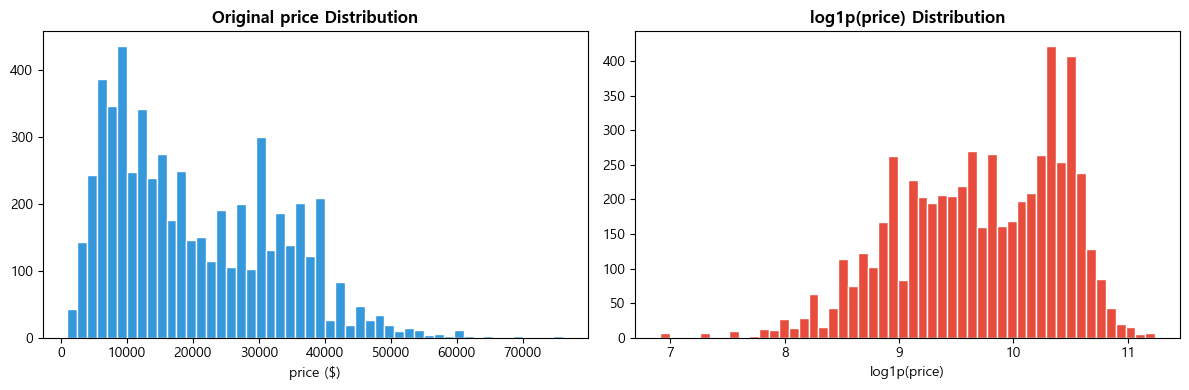

Original range: $1,000 ~ $76,100
Transformed range: 6.909 ~ 11.240


In [4]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train,     bins=50, color='#3498DB', edgecolor='white')
axes[0].set_title('Original price Distribution', fontweight='bold')
axes[0].set_xlabel('price ($)')
axes[1].hist(y_train_log, bins=50, color='#E74C3C', edgecolor='white')
axes[1].set_title('log1p(price) Distribution', fontweight='bold')
axes[1].set_xlabel('log1p(price)')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Original range: ${y_train.min():,.0f} ~ ${y_train.max():,.0f}')
print(f'Transformed range: {y_train_log.min():.3f} ~ {y_train_log.max():.3f}')

## Step 4. Function Definitions

### 4-1. encode_and_scale

Performs categorical feature encoding and numeric feature scaling.

- **Target Encoding** (`model` column): Converts vehicle model names to numeric values based on mean price. Fit on training data only to prevent data leakage.
- **Standard Scaling** (`odometer`, `vehicle_age`, `model_encoded`): Removes scale differences between features. Also fit on training data only.

### 4-2. adjusted_r2

Standard R² always increases as the number of features grows.  
**Adjusted R²** corrects for this by applying a penalty for the number of features.

$$\text{Adjusted } R^2 = 1 - (1 - R^2) \times \frac{n-1}{n-p-1}$$

| Symbol | Meaning |
|---|---|
| $n$ | Number of test samples |
| $p$ | Number of features |

Since the number of features changes at each step during iterative VIF removal, **Adjusted R² is used as the criterion for selecting the optimal step**.  
It also provides a fairer basis for comparing Baseline and Enhanced models that have different feature counts.

In [5]:
def encode_and_scale(X_train, X_test, y_train_log,
                     target_col='model',
                     scale_cols=['odometer', 'vehicle_age'],
                     smooth=10):
    """
    Target Encoding + Standard Scaling
    Fit on train data only → transform test data (prevent data leakage)
    """
    X_tr = X_train.copy()
    X_te = X_test.copy()

    te = None
    encoded_col = f'{target_col}_encoded'
    if target_col in X_tr.columns:
        te = TargetEncoder(smooth=smooth)
        X_tr[encoded_col] = te.fit_transform(X_tr[[target_col]], y_train_log).flatten()
        X_te[encoded_col] = te.transform(X_te[[target_col]]).flatten()
        X_tr.drop(columns=[target_col], inplace=True)
        X_te.drop(columns=[target_col], inplace=True)

    cols_to_scale = scale_cols + ([encoded_col] if te else [])
    cols_to_scale = [c for c in cols_to_scale if c in X_tr.columns]
    scaler = StandardScaler()
    X_tr[cols_to_scale] = scaler.fit_transform(X_tr[cols_to_scale])
    X_te[cols_to_scale] = scaler.transform(X_te[cols_to_scale])

    return X_tr, X_te, te, scaler


def adjusted_r2(r2, n, p):
    """
    Compute Adjusted R²

    Parameters
    ----------
    r2 : float  — standard R²
    n  : int    — number of test samples
    p  : int    — number of features

    Returns
    -------
    float — Adjusted R²
    """
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


print('Functions encode_and_scale and adjusted_r2 defined successfully')

Functions encode_and_scale and adjusted_r2 defined successfully


## Step 5. Define OHE Groups

Features generated by One-Hot Encoding (OHE) are derived from a single original column.  
For example, the `cylinders` column is split into `cylinders_3`, `cylinders_4`, `cylinders_5`, `cylinders_6`, etc.

In VIF analysis, if one OHE feature has a high VIF, removing only that feature causes **the VIF of remaining features in the same group to spike again**.  
Therefore, OHE features must be **removed as a complete group derived from the same original column**.

> Example: If `cylinders_6` has the highest VIF → remove all of `cylinders_3/4/5/8/12/other`

In [6]:
OHE_PREFIXES = [
    'cylinders', 'manufacturer', 'fuel', 'transmission',
    'type', 'title_status', 'drive', 'paint_color',
]

OHE_GROUPS = {}
for prefix in OHE_PREFIXES:
    group_feats = [c for c in numeric_feats if c.startswith(prefix + '_')]
    if group_feats:
        OHE_GROUPS[prefix] = group_feats

FEAT_TO_GROUP = {}
for group, feats in OHE_GROUPS.items():
    for f in feats:
        FEAT_TO_GROUP[f] = group

print('OHE group definitions:')
for group, feats in OHE_GROUPS.items():
    print(f'  {group:15s} ({len(feats)} features): {feats}')

OHE group definitions:
  cylinders       (7 features): ['cylinders_12', 'cylinders_3', 'cylinders_4', 'cylinders_5', 'cylinders_6', 'cylinders_8', 'cylinders_other']
  manufacturer    (16 features): ['manufacturer_chevrolet', 'manufacturer_chrysler', 'manufacturer_dodge', 'manufacturer_ford', 'manufacturer_gmc', 'manufacturer_honda', 'manufacturer_hyundai', 'manufacturer_jeep', 'manufacturer_kia', 'manufacturer_lexus', 'manufacturer_nissan', 'manufacturer_other', 'manufacturer_ram', 'manufacturer_subaru', 'manufacturer_toyota', 'manufacturer_volkswagen']
  fuel            (4 features): ['fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_other']
  transmission    (2 features): ['transmission_manual', 'transmission_other']
  type            (5 features): ['type_coupe', 'type_other', 'type_pickup', 'type_sedan', 'type_truck']
  title_status    (4 features): ['title_status_lien', 'title_status_missing', 'title_status_rebuilt', 'title_status_salvage']
  drive           (2 features): ['drive_

## Step 6. Iterative VIF Removal + Performance Tracking

### What is VIF (Variance Inflation Factor)?

VIF measures how well one feature is explained by other features, quantifying **multicollinearity between features**.

$$\text{VIF}_i = \frac{1}{1 - R^2_i}$$

Where $R^2_i$ is the coefficient of determination when regressing feature $i$ on the remaining features.  
Generally, **VIF ≥ 10** is considered to indicate multicollinearity.

> The target (price) is not included in VIF calculation. VIF measures only the relationships **among** features.

### Iterative Algorithm

Searching all feature combinations ($2^{50}$) is computationally infeasible.  
Instead, a **greedy approach** removes one feature at a time to find the optimal combination.

1. Calculate VIF for current features
2. Train Linear Regression on current features → record **R², Adjusted R², RMSE**
3. If all VIF < 10 → **stop**
4. Identify the feature with the highest VIF
   - OHE feature → remove the entire group
   - Regular feature → remove only that feature
5. Return to step 1

> **Why record Adjusted R² together**  
> Since the number of features changes at each step, R² alone does not allow fair comparison.  
> Adjusted R² applies a penalty for increasing feature count, enabling fair performance comparison across steps.

In [7]:
current_numeric = numeric_feats.copy()
history = []

print(f'Starting feature count: {len(current_numeric)}')
print('=' * 85)

step = 0
while len(current_numeric) > 1:

    # Calculate VIF
    vif_data  = X_train[current_numeric].copy()
    vif_const = add_constant(vif_data)
    vif_vals  = [
        variance_inflation_factor(vif_const.values, i + 1)
        for i in range(len(current_numeric))
    ]
    max_vif      = max(vif_vals)
    max_vif_feat = current_numeric[int(np.argmax(vif_vals))]

    # Train Linear Regression (excluding estimate_msrp — Baseline)
    feats     = current_numeric + ['model']
    X_tr_iter = X_train[feats].drop(columns=['estimate_msrp'], errors='ignore')
    X_te_iter = X_test[feats].drop(columns=['estimate_msrp'],  errors='ignore')

    sc = [c for c in ['odometer', 'vehicle_age'] if c in X_tr_iter.columns]
    X_tr_enc, X_te_enc, _, _ = encode_and_scale(
        X_tr_iter, X_te_iter, y_train_log, scale_cols=sc
    )

    lr = LinearRegression()
    lr.fit(X_tr_enc, y_train_log)
    y_pred = np.clip(np.expm1(lr.predict(X_te_enc)), 0, None)
    y_true = np.expm1(y_test_log)

    n_te   = len(y_true)
    p_te   = X_te_enc.shape[1]
    r2     = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2(r2, n_te, p_te)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))

    # Check OHE group → determine features to remove
    if max_vif_feat in FEAT_TO_GROUP:
        group_name      = FEAT_TO_GROUP[max_vif_feat]
        feats_to_remove = [f for f in OHE_GROUPS[group_name] if f in current_numeric]
        remove_label    = f'[OHE] {group_name} ({len(feats_to_remove)} features)'
    else:
        feats_to_remove = [max_vif_feat]
        remove_label    = max_vif_feat

    history.append({
        'step'         : step,
        'n_features'   : len(current_numeric),
        'max_vif'      : max_vif,
        'max_vif_feat' : max_vif_feat,
        'removed'      : feats_to_remove if max_vif >= 10 else [],
        'remove_label' : remove_label if max_vif >= 10 else '(none)',
        'R²'           : r2,
        'Adj. R²'      : adj_r2,
        'RMSE'         : rmse,
        'features'     : current_numeric.copy(),
    })

    print(f'Step {step:2d} | Features {len(current_numeric):2d} | Max VIF={max_vif:8.2f} ({max_vif_feat}) | R²={r2:.4f} | Adj.R²={adj_r2:.4f} | RMSE=${rmse:,.0f}')

    if max_vif < 10:
        print('\n All feature VIFs < 10 → stopping iteration')
        break

    if max_vif_feat in FEAT_TO_GROUP:
        print(f'       → Remove entire OHE group [{FEAT_TO_GROUP[max_vif_feat]}]: {feats_to_remove}')
    else:
        print(f'       → Remove: {max_vif_feat}')

    for f in feats_to_remove:
        if f in current_numeric:
            current_numeric.remove(f)

    step += 1

print('=' * 85)
print(f'Total {len(history)} steps completed')

Starting feature count: 50
Step  0 | Features 50 | Max VIF=  153.90 (title_status_missing) | R²=0.7495 | Adj.R²=0.7405 | RMSE=$6,594
       → Remove entire OHE group [title_status]: ['title_status_lien', 'title_status_missing', 'title_status_rebuilt', 'title_status_salvage']
Step  1 | Features 46 | Max VIF=  153.89 (cylinders_6) | R²=0.7346 | Adj.R²=0.7259 | RMSE=$6,786
       → Remove entire OHE group [cylinders]: ['cylinders_12', 'cylinders_3', 'cylinders_4', 'cylinders_5', 'cylinders_6', 'cylinders_8', 'cylinders_other']
Step  2 | Features 39 | Max VIF=    8.97 (manufacturer_ford) | R²=0.7160 | Adj.R²=0.7080 | RMSE=$7,021

 All feature VIFs < 10 → stopping iteration
Total 3 steps completed


## Step 7. Select Optimal Feature Combination (Based on Adjusted R²)

The stopping condition (all VIF < 10) and the optimal step selection criterion are different.

- **Stopping condition**: Stop search when all feature VIFs fall below 10
- **Optimal selection**: Select the feature combination from the step with the **highest Adjusted R²** among all explored steps

Since the number of features differs at each step, **Adjusted R²** must be used as the criterion — not simple R² —  
to select the feature combination with genuinely high predictive power without bias from increasing feature count.

Optimal Step  : Step 0  (based on Adjusted R²)
Feature count : 50 (+ model)
Max VIF    : 153.90
R²         : 0.7495
Adj. R²    : 0.7405
RMSE       : $6,594

Final selected features:
['model', 'condition', 'odometer', 'vehicle_age', 'estimate_msrp', 'cylinders_12', 'cylinders_3', 'cylinders_4', 'cylinders_5', 'cylinders_6', 'cylinders_8', 'cylinders_other', 'manufacturer_chevrolet', 'manufacturer_chrysler', 'manufacturer_dodge', 'manufacturer_ford', 'manufacturer_gmc', 'manufacturer_honda', 'manufacturer_hyundai', 'manufacturer_jeep', 'manufacturer_kia', 'manufacturer_lexus', 'manufacturer_nissan', 'manufacturer_other', 'manufacturer_ram', 'manufacturer_subaru', 'manufacturer_toyota', 'manufacturer_volkswagen', 'fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_other', 'transmission_manual', 'transmission_other', 'type_coupe', 'type_other', 'type_pickup', 'type_sedan', 'type_truck', 'title_status_lien', 'title_status_missing', 'title_status_rebuilt', 'title_status_salvage', 'drive_fwd', 

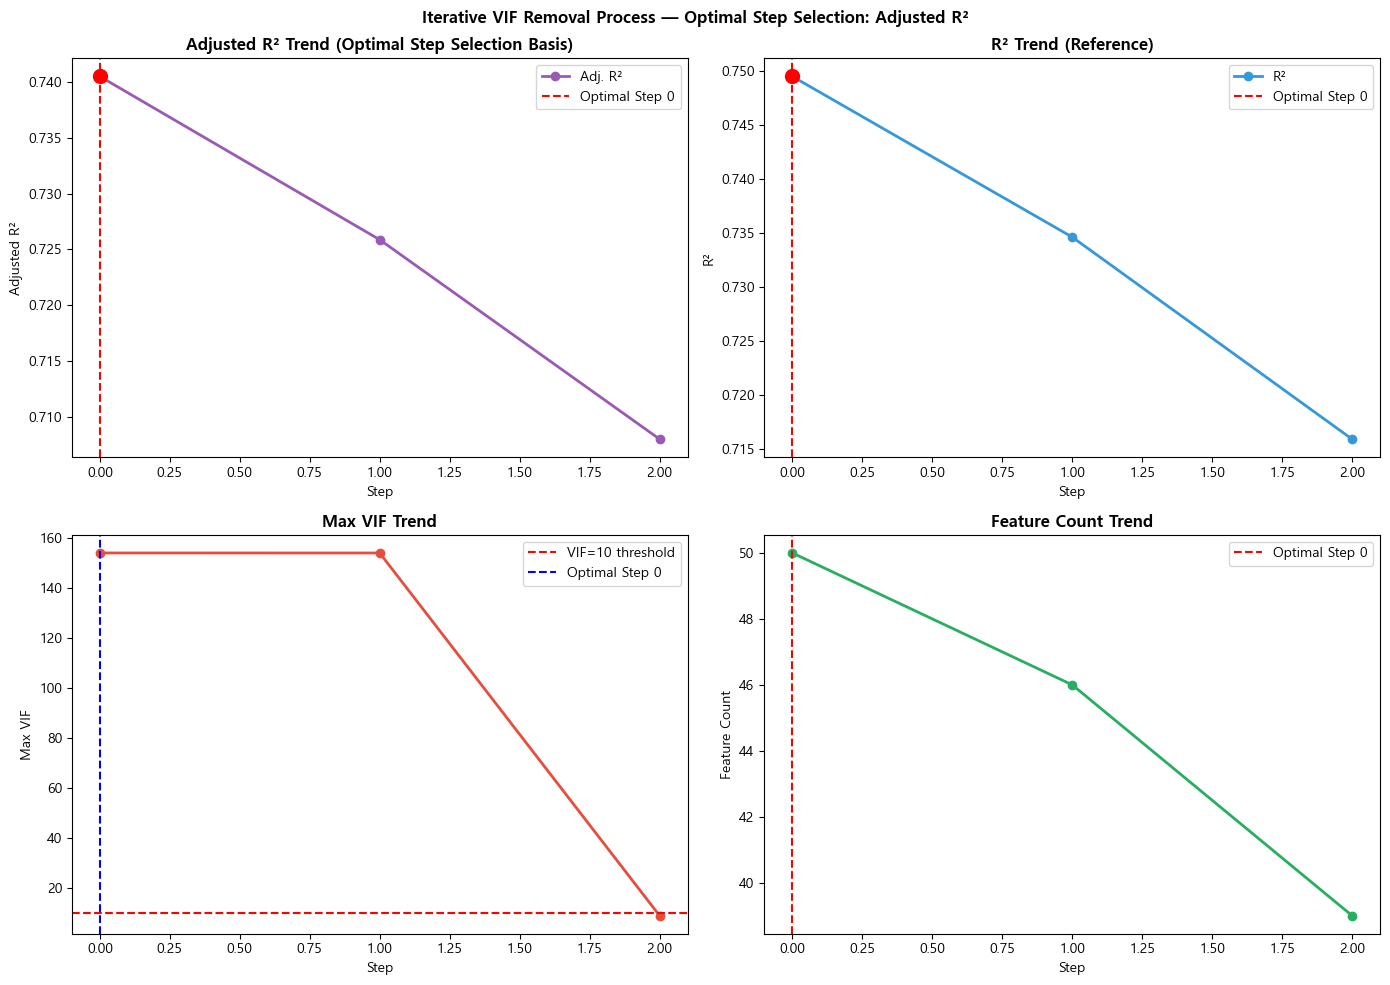

In [8]:
hist_df   = pd.DataFrame(history)
best_idx  = hist_df['Adj. R²'].idxmax()   # Select optimal step based on Adjusted R²
best_step = hist_df.loc[best_idx]

SELECTED_NUMERIC  = best_step['features']
SELECTED_FEATURES = ['model'] + SELECTED_NUMERIC

print(f'Optimal Step  : Step {int(best_step["step"])}  (based on Adjusted R²)')
print(f'Feature count : {len(SELECTED_NUMERIC)} (+ model)')
print(f'Max VIF    : {best_step["max_vif"]:.2f}')
print(f'R²         : {best_step["R²"]:.4f}')
print(f'Adj. R²    : {best_step["Adj. R²"]:.4f}')
print(f'RMSE       : ${best_step["RMSE"]:,.0f}')
print(f'\nFinal selected features:')
print(SELECTED_FEATURES)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
steps      = hist_df['step'].tolist()
n_features = hist_df['n_features'].tolist()
max_vifs   = hist_df['max_vif'].tolist()
r2s        = hist_df['R²'].tolist()
adj_r2s    = hist_df['Adj. R²'].tolist()

# Adjusted R² trend (basis for optimal step selection)
axes[0].plot(steps, adj_r2s, marker='o', color='#9B59B6', linewidth=2, label='Adj. R²')
axes[0].axvline(best_idx, color='red', linestyle='--', linewidth=1.5, label=f'Optimal Step {int(best_step["step"])}')
axes[0].scatter([best_idx], [best_step['Adj. R²']], color='red', s=100, zorder=5)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Adjusted R²')
axes[0].set_title('Adjusted R² Trend (Optimal Step Selection Basis)', fontweight='bold')
axes[0].legend()

# R² trend (reference)
axes[1].plot(steps, r2s, marker='o', color='#3498DB', linewidth=2, label='R²')
axes[1].axvline(best_idx, color='red', linestyle='--', linewidth=1.5, label=f'Optimal Step {int(best_step["step"])}')
axes[1].scatter([best_idx], [best_step['R²']], color='red', s=100, zorder=5)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('R²')
axes[1].set_title('R² Trend (Reference)', fontweight='bold')
axes[1].legend()

# Max VIF trend
axes[2].plot(steps, max_vifs, marker='o', color='#E74C3C', linewidth=2)
axes[2].axhline(10, color='red', linestyle='--', linewidth=1.5, label='VIF=10 threshold')
axes[2].axvline(best_idx, color='blue', linestyle='--', linewidth=1.5, label=f'Optimal Step {int(best_step["step"])}')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Max VIF')
axes[2].set_title('Max VIF Trend', fontweight='bold')
axes[2].legend()

# Feature count trend
axes[3].plot(steps, n_features, marker='o', color='#27AE60', linewidth=2)
axes[3].axvline(best_idx, color='red', linestyle='--', linewidth=1.5, label=f'Optimal Step {int(best_step["step"])}')
axes[3].set_xlabel('Step')
axes[3].set_ylabel('Feature Count')
axes[3].set_title('Feature Count Trend', fontweight='bold')
axes[3].legend()

plt.suptitle('Iterative VIF Removal Process — Optimal Step Selection: Adjusted R²', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('iterative_vif_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
display_df = hist_df[['step', 'n_features', 'max_vif', 'remove_label', 'R²', 'Adj. R²', 'RMSE']].copy()
display_df['RMSE']     = display_df['RMSE'].apply(lambda x: f'${x:,.0f}')
display_df['R²']       = display_df['R²'].apply(lambda x: f'{x:.4f}')
display_df['Adj. R²']  = display_df['Adj. R²'].apply(lambda x: f'{x:.4f}')
display_df['max_vif']  = display_df['max_vif'].apply(lambda x: f'{x:.2f}')
display_df.columns     = ['Step', 'Features', 'Max VIF', 'Removed Feature', 'R²', 'Adj. R²', 'RMSE']
display(display_df.style.apply(
    lambda row: ['background-color: #ffeaa7' if row['Step'] == int(best_step['step']) else '' for _ in row],
    axis=1
))

,Step,Features,Max VIF,Removed Feature,R²,Adj. R²,RMSE
0,0,50,153.90,[OHE] title_status (4 features),0.7495,0.7405,"$6,594"
1,1,46,153.89,[OHE] cylinders (7 features),0.7346,0.7259,"$6,786"
2,2,39,8.97,(none),0.7160,0.7080,"$7,021"


## Step 8. Baseline vs Enhanced Final Training and Evaluation

Based on the optimal feature combination selected through VIF analysis, train two models depending on whether the `estimate_msrp` feature is included.

| Model | Description |
|---|---|
| **Baseline** | Excludes `estimate_msrp` — trained without the LLM-generated feature |
| **Enhanced** | Includes `estimate_msrp` — trained with the additional LLM-generated feature |

Compare the performance of both models to verify whether `estimate_msrp` actually contributes to improved predictive power.

### Performance Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum\|y_i - \hat{y}_i\|$ | Mean Absolute Error (unit: $), lower is better |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | More sensitive to large errors, lower is better |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained by the model, closer to 1 is better |
| **Adjusted R²** | $1 - (1-R^2)\frac{n-1}{n-p-1}$ | R² with feature count penalty — **key metric for Baseline/Enhanced comparison** |

> Since Baseline and Enhanced have different feature counts ($p$ and $p+1$ respectively), simple R² comparison is biased in favor of Enhanced.  
> If Adjusted R² is also higher for Enhanced, it means `estimate_msrp` contributes **genuine predictive power**, not just the effect of adding a feature.

In [10]:
X_final = df[SELECTED_FEATURES].copy()
y_final = df['price'].copy()

X_tr_final, X_te_final, y_tr_final, y_te_final = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)
y_tr_log = np.log1p(y_tr_final)
y_te_log = np.log1p(y_te_final)

print('=== Baseline (excluding estimate_msrp) ===')
X_tr_base, X_te_base, _, _ = encode_and_scale(
    X_tr_final.drop(columns=['estimate_msrp'], errors='ignore'),
    X_te_final.drop(columns=['estimate_msrp'], errors='ignore'),
    y_tr_log
)
print()
print('=== Enhanced (including estimate_msrp) ===')
X_tr_enh, X_te_enh, _, _ = encode_and_scale(
    X_tr_final.copy(), X_te_final.copy(), y_tr_log
)

=== Baseline (excluding estimate_msrp) ===

=== Enhanced (including estimate_msrp) ===


In [11]:
def train_and_evaluate(config_name, X_tr, X_te, y_tr_log, y_te_log):
    """Train and evaluate Linear Regression (MAE, RMSE, R², Adjusted R²)"""
    model = LinearRegression()
    model.fit(X_tr, y_tr_log)
    y_pred = np.clip(np.expm1(model.predict(X_te)), 0, None)
    y_true = np.expm1(y_te_log)

    n  = len(y_true)    # number of test samples
    p  = X_te.shape[1]  # number of features
    r2 = r2_score(y_true, y_pred)

    return {
        'Config'  : config_name,
        'MAE'     : mean_absolute_error(y_true, y_pred),
        'RMSE'    : np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²'      : r2,
        'Adj. R²' : adjusted_r2(r2, n, p),
        'n'       : n,
        'p'       : p,
        'y_true'  : y_true,
        'y_pred'  : y_pred,
        'model'   : model,
        'X_test'  : X_te,
    }

res_base = train_and_evaluate('Baseline', X_tr_base, X_te_base, y_tr_log, y_te_log)
res_enh  = train_and_evaluate('Enhanced', X_tr_enh,  X_te_enh,  y_tr_log, y_te_log)

print(f'{"":12} {"MAE":>12} {"RMSE":>12} {"R²":>8} {"Adj. R²":>10} {"Features":>6}')
print('-' * 66)
for res in [res_base, res_enh]:
    print(f'{res["Config"]:12} ${res["MAE"]:>10,.0f} ${res["RMSE"]:>10,.0f} '
          f'{res["R²"]:>8.4f} {res["Adj. R²"]:>10.4f} {res["p"]:>6}')

                      MAE         RMSE       R²    Adj. R² Features
------------------------------------------------------------------
Baseline     $     4,006 $     6,589   0.7498     0.7408     50
Enhanced     $     3,558 $     5,738   0.8103     0.8033     51


## Step 9. Visualization

Two visualizations are used to assess model performance.

- **Performance comparison chart**: Compare Baseline vs Enhanced across four metrics: R², Adjusted R², RMSE, and MAE.
- **Actual vs Predicted**: Visualize the actual and predicted prices of the Enhanced model as a scatter plot. Points closer to the diagonal (perfect prediction line) indicate more accurate predictions.

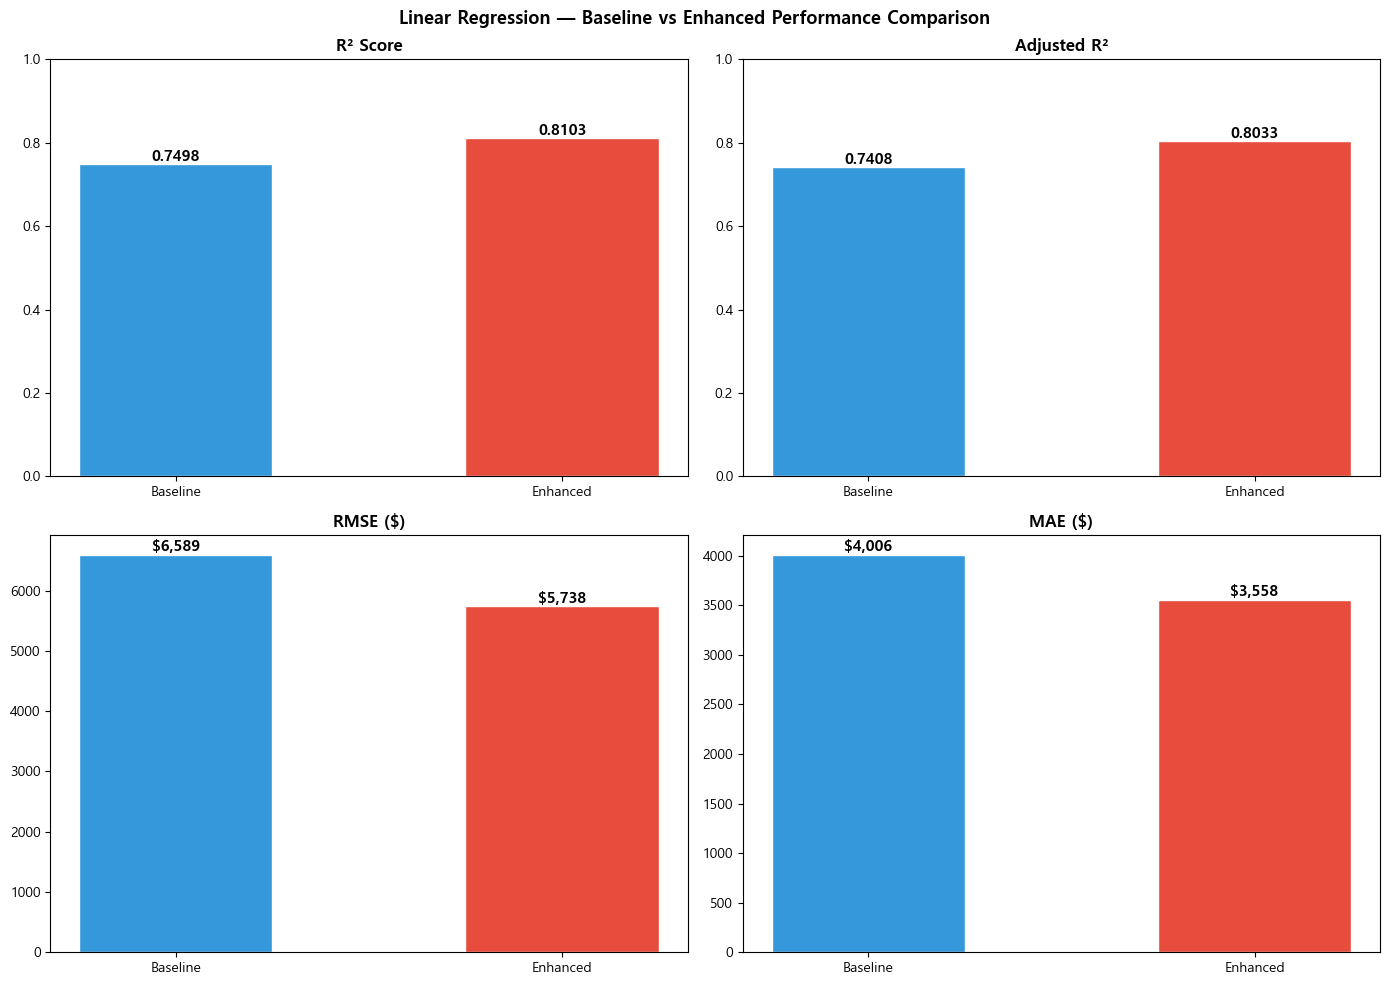

R²       change: 0.7498 → 0.8103  (+0.0604)
Adj. R²  change: 0.7408 → 0.8033  (+0.0625)
RMSE     change: $6,589 → $5,738  (+851$)
MAE      change: $4,006 → $3,558  (+448$)


In [12]:
# Performance comparison bar chart (R², Adjusted R², RMSE, MAE)
configs    = ['Baseline', 'Enhanced']
bar_colors = ['#3498DB', '#E74C3C']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = [
    ([res_base['R²'],      res_enh['R²']],      'R² Score',    '{:.4f}',  True),
    ([res_base['Adj. R²'], res_enh['Adj. R²']], 'Adjusted R²', '{:.4f}',  True),
    ([res_base['RMSE'],    res_enh['RMSE']],    'RMSE ($)',    '${:,.0f}', False),
    ([res_base['MAE'],     res_enh['MAE']],     'MAE ($)',     '${:,.0f}', False),
]

for ax, (vals, title, fmt, is_r2) in zip(axes, metrics):
    bars = ax.bar(configs, vals, color=bar_colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                fmt.format(val),
                ha='center', fontweight='bold', fontsize=11)
    if is_r2:
        ax.set_ylim(0, 1)

plt.suptitle('Linear Regression — Baseline vs Enhanced Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_enhanced.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'R²       change: {res_base["R²"]:.4f} → {res_enh["R²"]:.4f}  ({res_enh["R²"]-res_base["R²"]:+.4f})')
print(f'Adj. R²  change: {res_base["Adj. R²"]:.4f} → {res_enh["Adj. R²"]:.4f}  ({res_enh["Adj. R²"]-res_base["Adj. R²"]:+.4f})')
print(f'RMSE     change: ${res_base["RMSE"]:,.0f} → ${res_enh["RMSE"]:,.0f}  ({res_base["RMSE"]-res_enh["RMSE"]:+,.0f}$)')
print(f'MAE      change: ${res_base["MAE"]:,.0f} → ${res_enh["MAE"]:,.0f}  ({res_base["MAE"]-res_enh["MAE"]:+,.0f}$)')

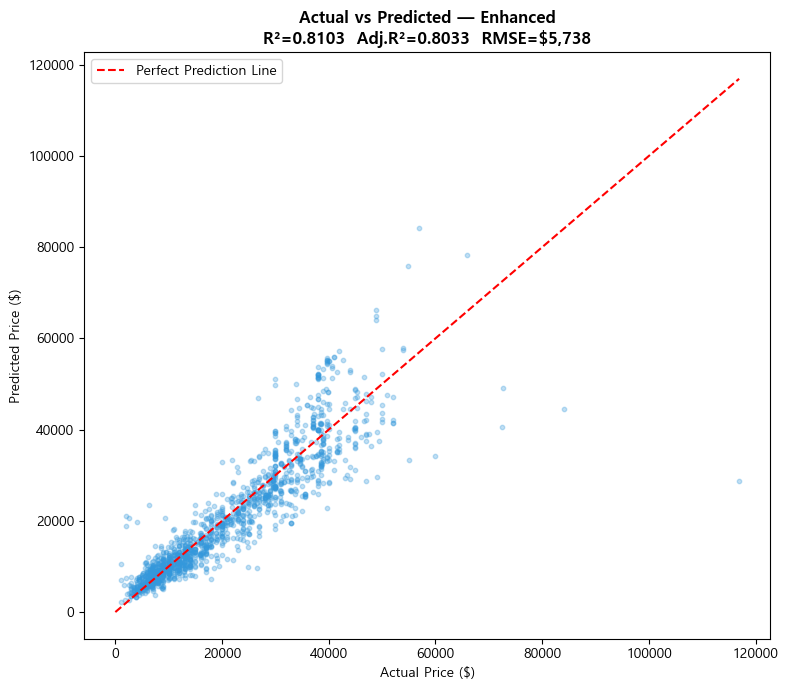

In [13]:
# Actual vs Predicted — Enhanced model
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(res_enh['y_true'], res_enh['y_pred'], alpha=0.3, s=10, color='#3498DB')
lim = max(res_enh['y_true'].max(), res_enh['y_pred'].max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect Prediction Line')
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.set_title(
    f'Actual vs Predicted — Enhanced\n'
    f'R²={res_enh["R²"]:.4f}  Adj.R²={res_enh["Adj. R²"]:.4f}  RMSE=${res_enh["RMSE"]:,.0f}',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10. Conclusion

### VIF Analysis Results

Through iterative VIF removal, the optimal feature combination was explored. The result showed that **Step 0 (all features)** yielded the highest Adjusted R².  
This means that removing features with multicollinearity actually degrades prediction performance.

The selected model's Max VIF exceeds 10, indicating **multicollinearity exists**.  
Multicollinearity is not a **complete assumption violation** of Linear Regression but rather an **instability** problem.  
That is, model training and prediction are still possible, but interpretation of individual regression coefficients is unreliable.

> Since the purpose of this analysis is **price prediction**, not interpretation of individual feature effects,  
> performance metrics (R², Adjusted R², RMSE, MAE) remain valid even in the presence of multicollinearity.

### Baseline vs Enhanced Comparison Results

The Enhanced model outperformed Baseline in all metrics: Adjusted R², RMSE, and MAE.  
In particular, since **Adjusted R² also increased** (which applies a penalty for feature count),  
it is confirmed that adding `estimate_msrp` is not merely the effect of increasing feature count but represents a **genuine improvement in predictive power**.

In [14]:
r2_diff     = res_enh['R²']      - res_base['R²']
adj_r2_diff = res_enh['Adj. R²'] - res_base['Adj. R²']
rmse_diff   = res_base['RMSE']   - res_enh['RMSE']
mae_diff    = res_base['MAE']    - res_enh['MAE']
removed_groups = [h['remove_label'] for h in history if h['removed']]

print('=' * 62)
print('           Linear Regression Analysis Conclusion')
print('=' * 62)

print(f'\n[1] Iterative VIF Removal Results (by OHE group)')
print(f'    Initial feature count : {len(numeric_feats)}')
print(f'    Total steps explored  : {len(history)}')
print(f'    Removed groups        : {removed_groups}')
print(f'    Optimal Step          : Step {int(best_step["step"])} (based on Adjusted R²) → {len(SELECTED_NUMERIC)} features + model')
print(f'    Optimal Max VIF       : {best_step["max_vif"]:.2f}  → multicollinearity present')
print(f'    → Individual regression coefficients are unreliable, but prediction metrics are valid')

print(f'\n[2] Baseline vs Enhanced Performance Comparison')
print(f'    {"":10} {"R²":>8} {"Adj. R²":>10} {"RMSE":>10} {"MAE":>10} {"Features":>6}')
print(f'    {"-"*58}')
print(f'    {"Baseline":10} {res_base["R²"]:>8.4f} {res_base["Adj. R²"]:>10.4f} ${res_base["RMSE"]:>9,.0f} ${res_base["MAE"]:>9,.0f} {res_base["p"]:>6}')
print(f'    {"Enhanced":10} {res_enh["R²"]:>8.4f} {res_enh["Adj. R²"]:>10.4f} ${res_enh["RMSE"]:>9,.0f} ${res_enh["MAE"]:>9,.0f} {res_enh["p"]:>6}')
print(f'    {"Change":10} {r2_diff:>+8.4f} {adj_r2_diff:>+10.4f} ${rmse_diff:>+9,.0f} ${mae_diff:>+9,.0f}')

print(f'\n[3] Impact of estimate_msrp Feature')
print(f'    Adj. R² change: {adj_r2_diff:+.4f}  (with feature count penalty)')
print(f'    RMSE    change: {rmse_diff:+,.0f}$')
print(f'    MAE     change: {mae_diff:+,.0f}$')
if adj_r2_diff > 0.005:
    print('    → Adjusted R² significantly improved → estimate_msrp is a genuinely useful feature ')
elif adj_r2_diff > 0:
    print('    → Adjusted R² slightly improved → estimate_msrp contributes modest predictive gain ')
else:
    print('    → Adjusted R² did not improve → estimate_msrp adds minimal predictive value')
print('=' * 62)

           Linear Regression Analysis Conclusion

[1] Iterative VIF Removal Results (by OHE group)
    Initial feature count : 50
    Total steps explored  : 3
    Removed groups        : ['[OHE] title_status (4 features)', '[OHE] cylinders (7 features)']
    Optimal Step          : Step 0 (based on Adjusted R²) → 50 features + model
    Optimal Max VIF       : 153.90  → multicollinearity present
    → Individual regression coefficients are unreliable, but prediction metrics are valid

[2] Baseline vs Enhanced Performance Comparison
                     R²    Adj. R²       RMSE        MAE Features
    ----------------------------------------------------------
    Baseline     0.7498     0.7408 $    6,589 $    4,006     50
    Enhanced     0.8103     0.8033 $    5,738 $    3,558     51
    Change      +0.0604    +0.0625 $     +851 $     +448

[3] Impact of estimate_msrp Feature
    Adj. R² change: +0.0625  (with feature count penalty)
    RMSE    change: +851$
    MAE     change: +448$
